In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import numpy as np
from pathlib import Path
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import binned_statistic_2d
import os
os.chdir(Path(os.getcwd()).parent.parent)  # Change to project root
from PIL import Image
# import metaworld
# import gymnasium as gym
# os.environ['MUJOCO_GL'] = 'egl'

In [2]:
all_envs = ['button', 'coffee', 'door', 'drawer', 'faucet']
configs = {env: {'pixel': [], 'dynamics': [], 'random': []} for env in all_envs}
for i in range(0, 1):
    for policy, objective in zip(['eig', 'maxdyn', 'random'], ['pixel', 'dynamics', 'random']):
        for env in all_envs:
            # if env == 'coffee' and objective == 'pixel':
            #     config = "runs/{env}/{env}_{objective}_{i}/config.yaml".format(env=env, objective=objective, i=5)
            # else:
            config = "runs/{env}/{env}_{objective}_{i}/config.yaml".format(env=env, objective=objective, i=i)
            configs[env][objective].append(config)

In [3]:
PROJECT_ROOT = Path("/home/ayush/Desktop/tutorials/rl_latent/E2C/")
env_name = all_envs[1]  # 'coffee'

idx = 13
paths = [cfg_path[0].split('/config.yaml')[0] for cfg_path in configs[env_name].values()]

pos_titles = [""]
states = [torch.load(PROJECT_ROOT / path / f'eval_states_{idx}.pt') for path in paths]
states_np = [s.cpu().numpy() if hasattr(s, "cpu") else np.asarray(s) for s in states]

# Add position titles with contact counts
for i in range(3):
    pos_titles.append(f"# Contacts: {np.count_nonzero(states_np[i][:, -1])}")

# Parameters
bins = 15
x_min, x_max = -0.45, 0.45
y_min, y_max = -0.2, 1.2

def hist2d_with_velocity(arr, bins):
    x, y = arr[:, 0], arr[:, 1]
    vx, vy, vz = arr[:, 8], arr[:, 9], arr[:, 10]
    vel = np.linalg.norm((vx, vy, vz), axis=0) / 4 / 3
    occ_pos, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[[x_min, x_max], [y_min, y_max]])
    occ_vel, _, _, _ = binned_statistic_2d(x, y, vel, bins=bins, range=[[x_min, x_max], [y_min, y_max]])
    
    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])
    return occ_pos, occ_vel, xc, yc, xedges, yedges

# Compute global min/max
all_occ_pos = []
for arr in states_np:
    occ_pos, occ_vel, _, _, xedges, yedges = hist2d_with_velocity(arr, bins)
    occ_pos_masked = np.where(occ_pos == 0, np.nan, occ_pos)
    all_occ_pos.append(occ_pos_masked)

pos_min = np.nanmin([np.nanmin(x) for x in all_occ_pos])
pos_max = np.nanmax([np.nanmax(x) for x in all_occ_pos])

# Create figure with 4 columns (image + 3 heatmaps)
fig = make_subplots(rows=1, cols=4, horizontal_spacing=0.05,
                    subplot_titles=pos_titles)
fig_width = 1400

# Load background image
img = Image.open("data_gen/temp_figs/coffee_topdown.png")

# Column 1: Add background image
fig.add_layout_image(
    dict(
        source=img,
        xref="x1",
        yref="y1",
        x=x_min,
        y=y_max,
        sizex=x_max - x_min,
        sizey=y_max - y_min,
        sizing="stretch",
        opacity=1.0,
        layer="above"
    )
)

# Columns 2-4: Add heatmaps with background images
for col, arr in enumerate(states_np, start=2):
    occ_pos, occ_vel, xc, yc, xedges, yedges = hist2d_with_velocity(arr, bins)
    occ_pos = np.where(occ_pos == 0, np.nan, occ_pos)

    # Add heatmap
    fig.add_trace(
        go.Heatmap(
            x=xc, y=yc, z=occ_pos.T, colorscale="peach",
            zmin=pos_min, zmax=pos_max,
            colorbar=dict(title="Timesteps", len=0.8, y=0.5),
            showscale=(col == 4)
        ),
        row=1, col=col
    )
    
    # Add markers
    start_x, start_y = arr[0, 0], arr[0, 1]
    end_x, end_y = arr[-1, 0], arr[-1, 1]
    fig.add_trace(
        go.Scatter(
            x=[start_x], y=[start_y], mode="markers",
            marker=dict(size=16, color="red", symbol="circle"),
            name="start pos", showlegend=(col == 2)
        ),
        row=1, col=col
    )
    fig.add_trace(
        go.Scatter(
            x=[end_x], y=[end_y], mode="markers",
            marker=dict(size=16, color="green", symbol="circle"),
            name="end pos", showlegend=(col == 2)
        ),
        row=1, col=col
    )
    
    # Add background image with 50% opacity
    fig.add_layout_image(
        dict(
            source=img,
            xref=f"x{col}",
            yref=f"y{col}",
            x=x_min,
            y=y_max,
            sizex=x_max - x_min,
            sizey=y_max - y_min,
            sizing="stretch",
            opacity=0.7,
            layer="below"
        )
    )

# Update axes for column 1 (image only)
fig.update_xaxes(range=[x_min, x_max], showticklabels=False, showgrid=False, 
                 zeroline=False, row=1, col=1)
fig.update_yaxes(range=[y_min, y_max], showticklabels=False, showgrid=False, 
                 zeroline=False, row=1, col=1)

# Update axes for columns 2-4 (heatmaps)
for c in range(2, 5):
    fig.update_xaxes(range=[x_min, x_max], row=1, col=c,
                    tickvals=xedges, showgrid=True, gridcolor='rgba(0, 0, 0, 1)',
                    showticklabels=False)
    fig.update_yaxes(range=[y_min, y_max], row=1, col=c,
                    tickvals=yedges, showgrid=True, gridcolor='rgba(0, 0, 0, 1)',
                    showticklabels=False)

# Draw borders around each subplot
for c in range(1, 5):
    fig.update_xaxes(showline=True, linewidth=1, linecolor="black", 
                    mirror=True, zeroline=False, row=1, col=c)
    fig.update_yaxes(showline=True, linewidth=1, linecolor="black", 
                    mirror=True, zeroline=False, row=1, col=c)

# Update layout
fig.update_layout(
    height=450, width=fig_width, template="plotly_white",
    title=dict(
        text=f"Coverage from Control Objectives",
        x=0.5, xanchor="center",
        y=0.9, yanchor="bottom",
        font=dict(size=36, family="Arial")
    ),
    margin=dict(l=50, r=120, t=120, b=20),
    hovermode=False,
    legend=dict(
        orientation="h",
        yanchor="top", y=-0.05,
        xanchor="center", x=0.5
    )
)
# Reduce spacing between columns - tighter spacing
fig['layout']['xaxis1']['domain'] = [0.0, 0.235]
fig['layout']['xaxis2']['domain'] = [0.255, 0.49]
fig['layout']['xaxis3']['domain'] = [0.51, 0.745]
fig['layout']['xaxis4']['domain'] = [0.765, 1.0]

# Add column titles
col_titles = ["Top Down View", "Pixel Objective", "Dynamic Objective", "Random"]
row_xs = [0.05, 0.375, 0.63, 0.935]
for i, text in enumerate(col_titles):
    fig.add_annotation(
        x=row_xs[i], y=1.2, xref="paper", yref="paper",
        text=text, showarrow=False,
        font=dict(size=24),
        align="center"
    )

# Nudge colorbars
for tr in fig.data:
    if isinstance(tr, go.Heatmap) and tr.colorbar:
        tr.update(colorbar=dict(x=1.02))

fig.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import gymnasium as gym
import metaworld
os.environ['MUJOCO_GL'] = 'egl'

all_envs = ['button', 'coffee', 'door', 'drawer', 'faucet']
configs = {env: {'pixel': [], 'dynamics': [], 'random': []} for env in all_envs}
for i in range(0, 1):
    for policy, objective in zip(['eig', 'maxdyn', 'random'], ['pixel', 'dynamics', 'random']):
        for env in all_envs:
            config = "runs/{env}/{env}_{objective}_{i}/config.yaml".format(env=env, objective=objective, i=i)
            configs[env][objective].append(config)

env_name = all_envs[3]  # 'door'
idx = 2
paths = [cfg_path[0].split('/config.yaml')[0] for cfg_path in configs[env_name].values()]

pos_titles = [""]
states = [torch.load(PROJECT_ROOT / path / f'eval_states_{idx}.pt') for path in paths]
states_np = [s.cpu().numpy() if hasattr(s, "cpu") else np.asarray(s) for s in states]

In [76]:
action_sequences = np.zeros((120, 4))
action_sequences[:20, 1] = 0.2  # y-axis
# action_sequences[30:60, 0] = 0.25
action_sequences[30:60, 2] = -0.2
# action_sequences[60:80, 2] = -0.2
action_sequences[80:120, 1] = -0.2  # y-axis back
states_np = [torch.load("/home/ayush/Desktop/tutorials/rl_latent/E2C/runs/faucet/faucet_pixel_0/eval_states_0_keep.pt").cpu().numpy()]

In [77]:
env = gym.make('Meta-World/MT1', env_name='faucet-open-v3', render_mode='rgb_array', camera_name='corner')
obs, _ = env.reset()

# Collect all frames
frames = []
for action in states_np[0][:, 8:-1]:  # gripper + obj pos
# for action in action_sequences:  # gripper + obj pos
    for _ in range(4):
        obs, reward, done, truncated, info = env.step(action)
    if truncated:
        print('forced to reset')
        obs, _ = env.reset()
    img = env.render()
    frames.append(np.rot90(img, k=2))

# Create animation
fig, ax = plt.subplots(figsize=(8, 6))
ax.axis('off')
im = ax.imshow(frames[0])

def update(frame_idx):
    im.set_array(frames[frame_idx])
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(frames), 
                             interval=50, blit=True, repeat=True)

# Save as MP4
output_path = 'faucet_rollout.mp4'
ani.save(output_path, writer='ffmpeg', fps=20, dpi=100)
print(f"Animation saved to {output_path}")

plt.close()

# Optional: Display in notebook
HTML(ani.to_html5_video())

/home/ayush/.local/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:35: UserWarning:

WARN: A Box observation space maximum and minimum values are equal.

/home/ayush/.local/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning:

WARN: The obs returned by the `reset()` method is not within the observation space.

/home/ayush/.local/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning:

WARN: The obs returned by the `step()` method is not within the observation space.



Animation saved to drawer_rollout.mp4


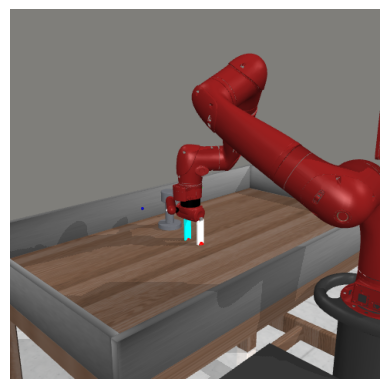

In [ ]:
# write a script that saves a given index from frame
idx = 96
im_to_save = frames[idx]  # specify the index here
plt.imshow(im_to_save)
plt.axis('off')
plt.show()
plt.imsave(f'data_gen/temp_figs/frame_{idx}.png', im_to_save)